### **Latent Space Analysis and Visualisation**

In [1]:
import sys
from typing import Any, NamedTuple

from tqdm import tqdm
import torch
from torch.types import Tensor


class LatentVector(NamedTuple):
    """Latent vector container."""
    vals: Tensor
    lbls: Tensor


def get_size(obj: object, default: Any = -1) -> int:
    """Computes how much memory storage is being used by input obj in [bytes]."""
    return sys.getsizeof(obj, default=default)

In [3]:
# BASEPATH: str = '/home/edoardo/Desktop/MockDataForDMs'
BASEPATH: str = '/mnt/d/MockDataForDMs'

# file_id: str = 'latentSpaceContainer'
file_id: str = 'latentSpaceContainer_mockVAEmodel_MNIST'

latent_dmap: dict[int, LatentVector] = torch.load(f'{BASEPATH}/{file_id}.pt', weights_only=False)

print(
    f'Latent Space dmap size: {get_size(latent_dmap)} bytes\n'
    f'Number of epochs registered: {len(latent_dmap)}\n'
    f'Embedded data size: vector = {latent_dmap[0].vals.shape}, lbls = {latent_dmap[0].lbls.shape}\n'
)

# NOTE:
#   - a tensor of shape [E, B, C, H, W] occupies less memory than the latent dict map
#   - when saved though, the 5D tensor occupies x2 space (dmap: ~13.7MB, tensor: ~27  MB)
#   - this has been tested on 5 epochs (TODO: test if for larger # of epochs is the same)

Latent Space dmap size: 4688 bytes
Number of epochs registered: 100
Embedded data size: vector = torch.Size([3000, 32]), lbls = torch.Size([3000])



In [4]:
from itertools import islice

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

import umap


def manage_latent_data(latent_dmap: dict[int, LatentVector]) -> dict[int, tuple[NDArray, NDArray]]:
    """
    Takes the data in the latent dmap and for each epoch flattens the respective embedded
    vector to a tensor [B, C x H x W], finally converting it to a numpy array.
    """
    # use `islice` bc `latent_dmap` could be very large (epochs
    # number + respective tensors with all the latent vectors)
    flattened_dmap: dict[int, NDArray] = {
        epoch: (emb.vals.flatten(1, -1).numpy(), emb.lbls.numpy())
        for epoch, emb in islice(latent_dmap.items(), len(latent_dmap))
    }
    return flattened_dmap


def UMAP_dim_reducer(
    data: NDArray,
    n_neighbors: int,
    min_dist: float,
    n_components: int = 2,
    metric: str = 'euclidean',
    **kwards: Any,
) -> NDArray:
    """
    Reduces the dimensionality of the input data with UMAP.
    NOTE: the fit should be performed on processed data
        * remove NaNs
        * avoid different data scales (e.g., convert features
          into z-scores --# of std from mean-- for comparability).
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric=metric,
        **kwards,
    )
    embedding = reducer.fit_transform(data)
    return embedding


def plot_latent_space(
    embedding: NDArray,
    title: str | None = None,
    labels: NDArray | None = None,
    labels_dmap: dict[int, 'str'] | None = None,
) -> None:
    """Plots the 2D latent space."""
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=10)
    plt.gca().set_aspect('equal', 'datalim')
    if labels_dmap is not None:
        cbar = plt.colorbar(boundaries=np.arange(len(labels_dmap) + 1) - 0.5)
        cbar.set_ticks(np.arange(len(labels_dmap)), labels=list(labels_dmap.values()))
    if title is not None: plt.title(title, fontsize=12)
    plt.show()
    return


def plot_latent_evolution(
    epochs: tuple[int, ...],
    latent_dmap: dict[int, tuple[NDArray, NDArray]],
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    labels_dmap: dict[int, 'str'] | None = None,
    **umap_kwards: Any,
) -> None:
    """Shows the latent space distribution at the given epochs."""
    epochs_ = (epochs,) if not isinstance(epochs, tuple) else epochs
    for epoch in tqdm(epochs_):
        epoch_latent_vector, epoch_lbls = latent_dmap[epoch]
        embedding = UMAP_dim_reducer(
            data=epoch_latent_vector,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            **umap_kwards,
        )
        plot_latent_space(
            embedding=embedding,
            title=f'UMAP Proj.: Latent Space Epoch {epoch}',
            labels=epoch_lbls,
            labels_dmap=labels_dmap,
        )
    return


def plot_latent_vecfield(
    latent_dmap: dict[int, tuple[NDArray, NDArray]],
    start_epoch: int,
    end_epoch: int,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    samples_fract: float = 0.5,
    # labels_dmap: dict[int, 'str'] | None = None,
    **umap_kwards: Any,
) -> None:
    """Plots the latent space evolving vector field between epochs."""
    # NOTE - maybe it's better with:
    #   - no scatter points
    #   - show vector field with a step of ~1/2 epochs
    #   - OPTIONAL - different arrows color by class

    # extract latent vector and compute embeddings
    vec_start, _ = latent_dmap[start_epoch]
    vec_end, lbls = latent_dmap[end_epoch]
    # NOTE: mantain physical samples mapping between start and end embedd points
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, **umap_kwards)
    emb_end = reducer.fit_transform(vec_end)
    emb_start = reducer.transform(vec_start)
    # extract vector field latent samples and displacements
    n_points = len(vec_start)
    idxs = np.random.choice(n_points, int(samples_fract * n_points), replace=False)
    samples_start, samples_end = emb_start[idxs], emb_end[idxs]
    dx, dy = (
        samples_end[:, 0] - samples_start[:, 0],
        samples_end[:, 1] - samples_start[:, 1],
    )
    # plot vector field
    # # scatter = plt.scatter(emb_end[:, 0], emb_end[:, 1], c=lbls, alpha=0.5, cmap='Spectral', s=5)
    # # if labels_dmap is not None:
    # #     cbar = plt.colorbar(scatter, boundaries=np.arange(len(labels_dmap) + 1) - 0.5)
    # #     cbar.set_ticks(np.arange(len(labels_dmap)), labels=list(labels_dmap.values()))
    plt.quiver(
        samples_start[:, 0], samples_start[:, 1], dx, dy, lbls[idxs],
        angles='xy', scale_units='xy', scale=1, alpha=0.6,
        cmap='Spectral', width=0.002, headwidth=3, headlength=4,
    )
    plt.title(f"Latent Drift: Epoch {start_epoch} to {end_epoch}")
    plt.grid(True, linestyle='-', alpha=0.75, linewidth=0.1)
    plt.tight_layout()
    plt.show()
    return

In [5]:
CLASS_NAMES: dict[int, str] = {
    0: 'circle',
    1: 'triangle',
    2: 'square',
    3: 'hexagon',
}
CLASS_NAMES: dict[int, str] = {val: str(val) for val in range(10)}

N_NEIGHBORS: int = 15
MIN_DIST: float = 0.1
KWDS : dict[str, Any] = {}


np_emb: dict[int, NDArray] = manage_latent_data(latent_dmap)

  0%|          | 0/6 [00:00<?, ?it/s]

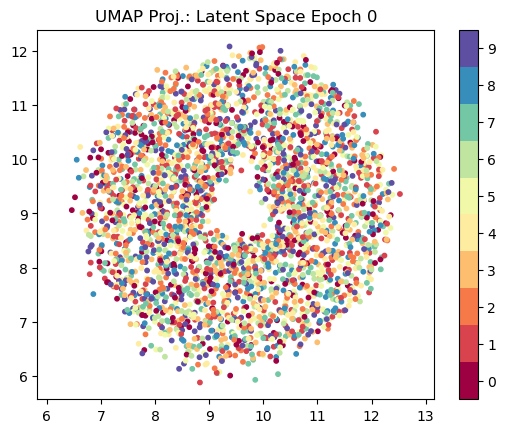

 17%|█▋        | 1/6 [00:16<01:20, 16.13s/it]

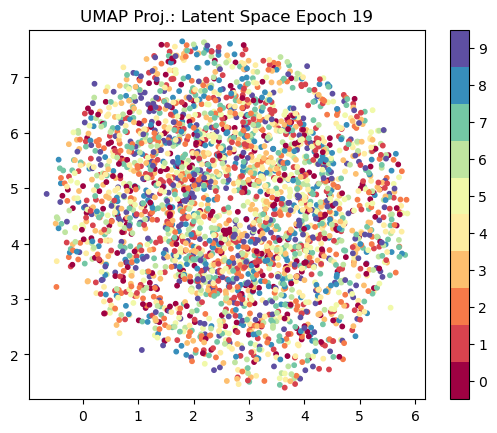

 33%|███▎      | 2/6 [00:26<00:51, 12.95s/it]

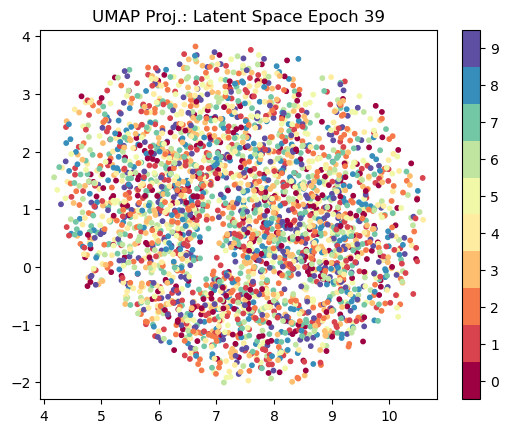

 50%|█████     | 3/6 [00:37<00:36, 12.06s/it]

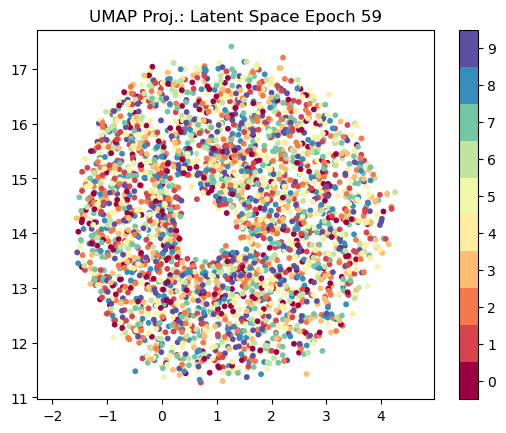

 67%|██████▋   | 4/6 [00:48<00:23, 11.61s/it]

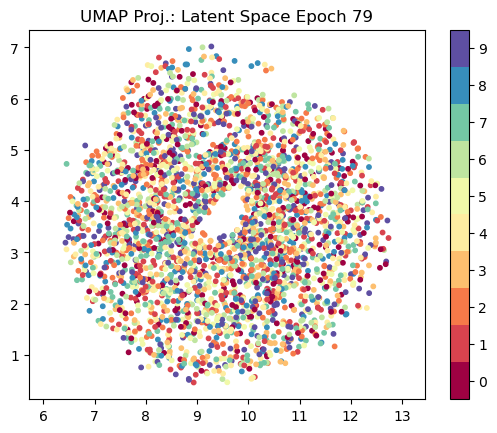

 83%|████████▎ | 5/6 [00:59<00:11, 11.33s/it]

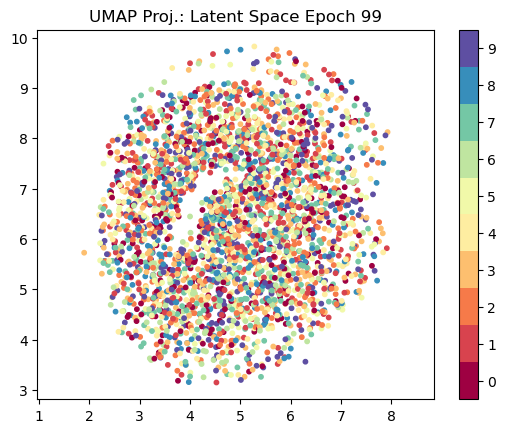

100%|██████████| 6/6 [01:10<00:00, 11.70s/it]


In [6]:
plot_latent_evolution(
    epochs=(0, 19, 39, 59, 79, 99),
    latent_dmap=np_emb,
    n_neighbors=40,
    min_dist=0.5,
    labels_dmap=CLASS_NAMES,
)

In [ ]:
import torch.nn as nn
import stardust as sd
# from BASE_mockModels import MockVAE

class BaseEncoder(nn.Module):
    """Baseline mock encoder model."""
    def __init__(self, in_channels: int, hid_channel: int, latent_dim: int) -> None:
        super().__init__()
        self.architecture = nn.Sequential(
            nn.Conv2d(in_channels, hid_channel, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.Conv2d(hid_channel, hid_channel, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.Conv2d(hid_channel, hid_channel, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(hid_channel, hid_channel, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(hid_channel, latent_dim, kernel_size=4, stride=1),
        )
    
    def forward(self, x: Tensor) -> Tensor:
        out = self.architecture(x)
        return out

class BaseDecoder(nn.Module):
    """Baseline mock encoder model."""
    def __init__(self, latent_dim: int, hid_channel: int, out_channels: int) -> None:
        super().__init__()
        self.architecture = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hid_channel, kernel_size=4, stride=1),
            nn.ReLU(),
            nn.ConvTranspose2d(hid_channel, hid_channel, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(hid_channel, hid_channel, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(hid_channel, hid_channel, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.ConvTranspose2d(hid_channel, out_channels, kernel_size=5, stride=1),
        )
    
    def forward(self, x: Tensor) -> Tensor:
        out = self.architecture(x)
        return out

class MockVAE(nn.Module):
    """
    Baseline mock Variational AutoEncoder model for `spark` API tests and stuff.
    """
    def __init__(
        self,
        latent_dim: int,
        in_channels: int = 1,
        hid_channel: int = 32,
    ) -> None:
        super().__init__()
        self.encoder = BaseEncoder(in_channels, hid_channel, latent_dim)
        self.fc_estim_mean = nn.Linear(latent_dim, latent_dim)
        self.fc_estim_log_var = nn.Linear(latent_dim, latent_dim)
        self.decoder = BaseDecoder(latent_dim, hid_channel, in_channels)
    
    def encode_signal(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """
        Encodes the input signal, returning mean and log variance
        estimators for the latent space prob. distribution.
        """
        out = self.encoder(x).flatten(1, -1)
        mean = self.fc_estim_mean(out)
        log_var = self.fc_estim_log_var(out)
        return mean, log_var
    
    def reparameterize(self, mean: Tensor, log_var: Tensor) -> Tensor:
        """Reparameterization Trick for latent space tractable sampling."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(mean)
        z = mean + eps * std
        return z.view(z.size(0), z.size(1), 1, 1)
    
    def forward(self, x: Tensor) -> Tensor:
        mean, log_var = self.encode_signal(x)
        z = self.reparameterize(mean, log_var)
        out = self.decoder(z)
        return out, mean, log_var

LATENT_DIM: int = 32
vae = MockVAE(LATENT_DIM, hid_channel=2*LATENT_DIM)

model_path: str = f'{BASEPATH}/mockVAEmodel_MNIST.pt'
model_data = sd.load_model(model_path)

vae.load_state_dict(model_data['state_dict'])

Loading model...
Model loaded!


<All keys matched successfully>

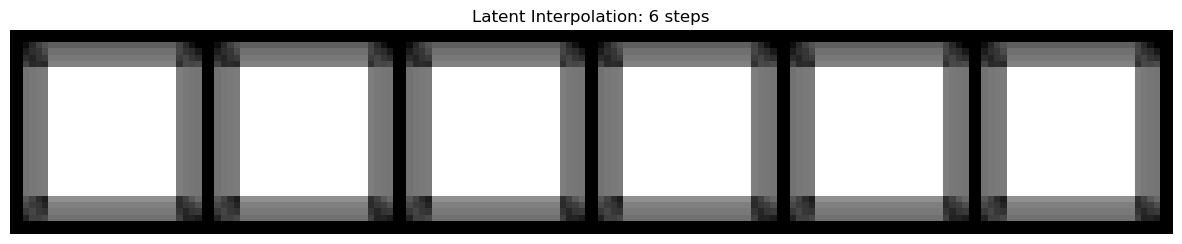

In [ ]:
import torch.nn as nn
from torch.amp import autocast
from torchvision.utils import make_grid

@torch.no_grad()
def explore_latent_space(
    model: nn.Module,
    start: Tensor,
    end: Tensor,
    steps: int = 5,
) -> None:
    """Interpolates between two samples in the latent space distr."""
    model.eval().cpu()
    # vectorize ops
    alpha = torch.linspace(0, 1, steps)
    interp_vecs = (1 - alpha[:, None]) * start + alpha[:, None] * end
    # comp interpolation and back
    eta = interp_vecs.view(steps, -1, 1, 1)
    with autocast(device_type='cpu'):
        xi = model.decoder(eta)
    # plot grid
    grid = make_grid(xi.float(), nrow=steps, normalize=True, padding=2)
    # permute moves channels to the end: (C, H, W) -> (H, W, C)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(15, 5))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title(f"Latent Interpolation: {steps} steps")
    plt.show()
    return


epoch_latent_samples, epoch_lbls = latent_dmap[99]
explore_latent_space(vae, epoch_latent_samples[10, :], epoch_latent_samples[70, :], steps=6)

In [9]:
assert False

AssertionError: 

In [ ]:
plot_latent_vecfield(
    latent_dmap=np_emb,
    start_epoch=0,
    end_epoch=49,
    labels_dmap=CLASS_NAMES,
)

In [ ]:
EPOCH: int = 0

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]
embedding = UMAP_dim_reducer(
    data=epoch_latent_vector,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    **KWDS,
)
plot_latent_space(
    embedding=embedding,
    title=f'UMAP Proj.: Latent Space Epoch {EPOCH}',
    labels=epoch_lbls,
    labels_dmap=CLASS_NAMES,
)

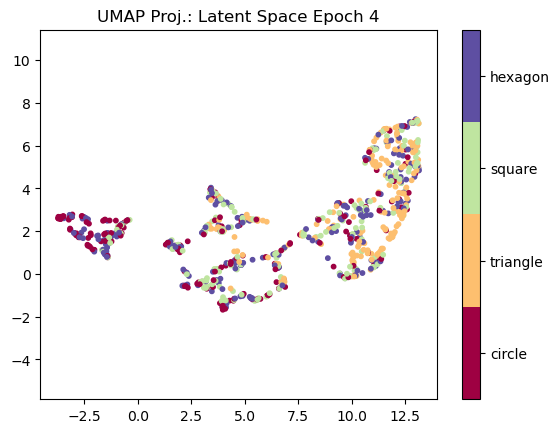

In [ ]:
EPOCH: int = 4

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]
embedding = UMAP_dim_reducer(
    data=epoch_latent_vector,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    **KWDS,
)
plot_latent_space(
    embedding=embedding,
    title=f'UMAP Proj.: Latent Space Epoch {EPOCH}',
    labels=epoch_lbls,
    labels_dmap=CLASS_NAMES,
)

In [ ]:
assert False

In [ ]:
import umap.plot as upt

upt.points(embedding)

/home/starfloyd/anaconda3/envs/spark/lib/python3.13/site-packages/umap/plot.py:20: UserWarning: The umap.plot package requires extra plotting libraries to be installed.
    You can install these via pip using

    pip install umap-learn[plot]

    or via conda using

     conda install pandas matplotlib datashader bokeh holoviews colorcet scikit-image
    
  warn(


ImportError: umap.plot requires pandas matplotlib datashader bokeh holoviews scikit-image and colorcet to be installed